### Overview

Co-occurence analysis of PAM50 gene clusters based on their rankings

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 1. Import and prepare data

In [3]:
# import PAM50 genes
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [7]:
# import tpm counts train data
train = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [8]:
# check dimension
print(train.shape)

(2204, 52)


In [9]:
train['subtype'] = train['subtype'].replace({'Her2': 'HER2'})

In [10]:
train['subtype'].value_counts()

subtype
LumA     1119
LumB      654
Basal     230
HER2      201
Name: count, dtype: int64

In [11]:
# check whether the ensemble id column order match with that of in the pam50 df
train.columns[0:50].tolist() == pam50['ensembl_gene_id'].tolist()

True

In [12]:
# extract counts
train_counts = train.iloc[:, 0:50]

# rename columns
train_counts.columns = pam50['new_gene_symbol'].tolist()

# replace gene values by the rank
train_ranked = train_counts.rank(axis=1, method="min", ascending=False).astype('int')
print(train_ranked.shape)

(2204, 50)


#### 2. Boxplot of rank distribution of genes in the training set arranged according to the semantic similarity
##### The gene order was determined from hierarchical clustering of word2vec-derived gene embeddings

In [13]:
# import hierarchical clustering results
hier_cluster_res = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/pam50_classification_word2vec/pam50_gene_embedding_functional_analysis/hierarchical_clusters_pam50_word2vec_embedding_sorted.csv",
                               header=0)

In [14]:
# make a dictionary of the gene (key) and cluster label (value)
gene_hier_cluster = {}
for gene in hier_cluster_res['new_gene_symbol']:
    cluster = hier_cluster_res.loc[hier_cluster_res['new_gene_symbol']==gene,'hier_cluster'].values[0]
    gene_hier_cluster[gene] = cluster

In [15]:
# reorder the train_ranked dataset columns according to the order of genes sorted according to the cluster label
train_ranked_reordered = train_ranked[hier_cluster_res['new_gene_symbol'].tolist()]

# merge the dataset with subtype labels
train_ranked_reordered_subtype = train_ranked_reordered.join(train.loc[:,'subtype'])
train_ranked_reordered_subtype.shape

(2204, 51)

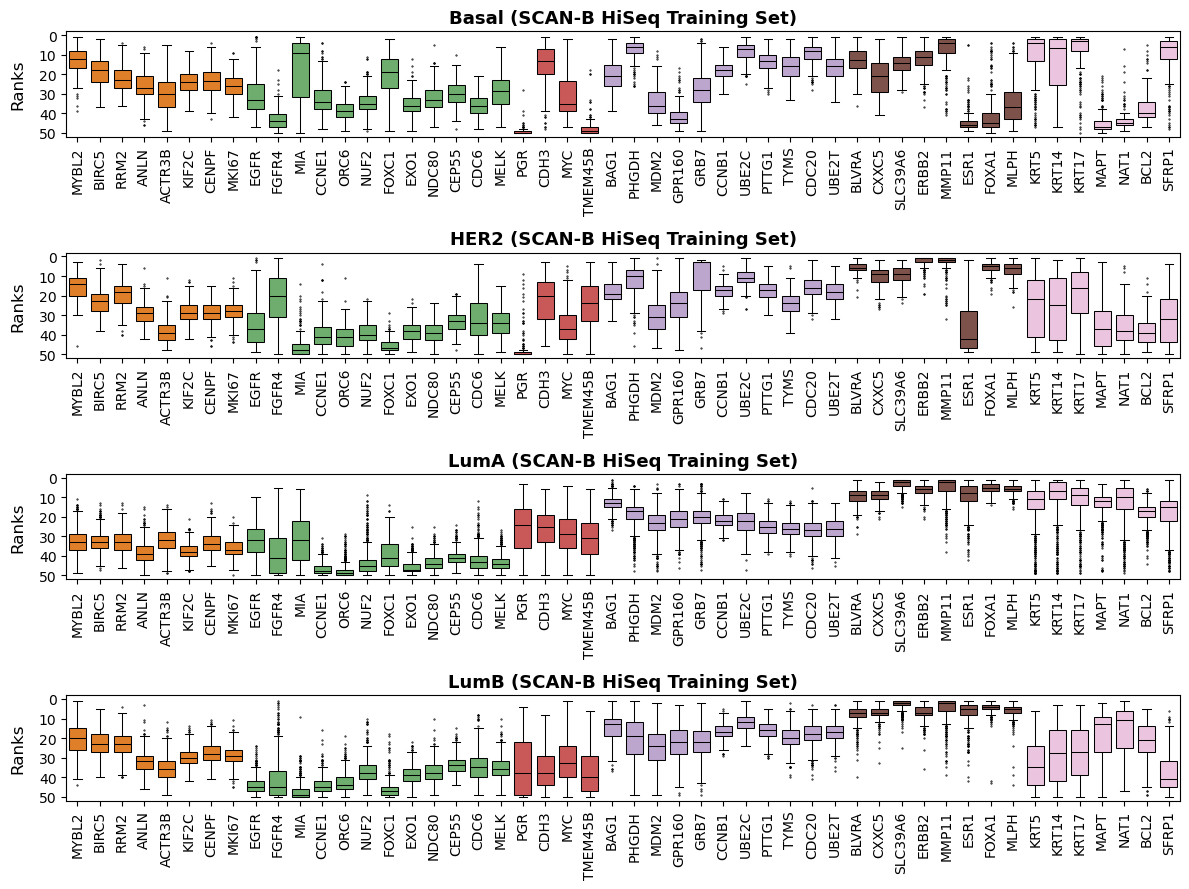

In [16]:
# boxplot of basal subtype for all datasets
subtypes = ['Basal', 'HER2', 'LumA', 'LumB']
custom_palette_hier_cluster = {1: '#FF7D0B', #orange shade
        2: '#63B863', #green shade
        3: '#DC4647', #red shade
        4: '#BC9FD5', #light purple shade
        5: '#854C41', #brown shade
        6: '#F2BEE2', #pink shade
                              }
plt.figure(figsize=(12, 9))
for i in range(len(subtypes)):
    plt.subplot(4, 1, i+1)
    data_subtype = train_ranked_reordered_subtype.loc[train_ranked_reordered_subtype['subtype']==subtypes[i]].drop(columns=['subtype'])
    data_subtype_long = data_subtype.melt(var_name='gene', value_name='ranks')
    data_subtype_long['gene_cluster'] = data_subtype_long['gene'].map(gene_hier_cluster)
    sns.boxplot(x='gene', y='ranks', data=data_subtype_long, gap=0.05, linewidth=0.75, hue='gene_cluster',
              palette=custom_palette_hier_cluster, fliersize=0.5, linecolor='black', width=0.8, legend=False)
    plt.title(f'{subtypes[i]} (SCAN-B HiSeq Training Set)', fontdict={'size':13, 'color':'black', 'family':'sans-serif', 'weight': 'bold'})
    plt.xticks(fontsize=10, color='black', fontfamily='sans-serif', rotation=90)
    plt.yticks(np.arange(0, 60, 10), fontsize=10, color='black', fontfamily='sans-serif')
    plt.ylim(52,-2)
    plt.ylabel('Ranks', fontdict={'size':12, 'color':'black', 'family':'sans-serif'}, labelpad=10)
    plt.xlabel('', fontdict={'size':12, 'color':'black', 'family':'sans-serif'}, labelpad=10)
plt.tight_layout()
# plt.savefig('pam50_gene_embedding_rank_distribution_trainset.png', dpi=300, bbox_inches='tight')
plt.show()